## Import Libraries

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys
from IPython.display import Image

project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))
os.chdir(project_root)

from fmu2ml.analysis.input_output_relations.analyzers import DirectEffectAnalyzer, DataGenerator
from fmu2ml.analysis.input_output_relations.visualizers import *
from raps.config import ConfigManager

sns.set_style("whitegrid")
%matplotlib inline


## Define Parameters

In [2]:
SYSTEM_NAME = 'lassen'
config = ConfigManager(system_name=SYSTEM_NAME).get_config()


In [3]:
config['NUM_CDUS']

44

In [5]:
OUTPUT_DIR = f'../results/{SYSTEM_NAME}/data_analysis/direct_effect_analysis'
os.makedirs(OUTPUT_DIR, exist_ok=True)


SAMPLES_PER_HOUR = 60
TOTAL_TIMESTEPS = 7200

# Input ranges
INPUT_RANGES = {
    'Q_flow': (config.get('MIN_POWER'), config.get('MAX_POWER')),    # kW
    'T_Air': (288.15, 308.15),   # K
    'T_ext': (283.15, 313.15)    # K
}

# Parallel settings
N_WORKERS = 48
THREADS_PER_WORKER = 1
MEMORY_LIMIT = '256GB'

print(f"System: {SYSTEM_NAME}")
print(f"Workers: {N_WORKERS}")
print(f"Total timesteps: {TOTAL_TIMESTEPS}")
print(f"Samples per hour: {SAMPLES_PER_HOUR}")


System: lassen
Workers: 48
Total timesteps: 7200
Samples per hour: 60


## Load or Generate Data

In [6]:

data_generator = DataGenerator(
    n_workers=N_WORKERS,
    **config
)

analyzer = DirectEffectAnalyzer(
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    **config
)

print(f"Number of CDUs: {config.get('NUM_CDUS', 45)}")
print(f"Initialized analyzers")


2026-02-03 18:59:55 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - DataGenerator initialized for system: lassen
2026-02-03 18:59:55 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - Number of CDUs: 44
2026-02-03 18:59:55 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - DirectEffectAnalyzer initialized for system: lassen
2026-02-03 18:59:55 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Number of CDUs: 44


Number of CDUs: 44
Initialized analyzers


In [8]:
data_file = os.path.join(OUTPUT_DIR, 'sensitivity_data.parquet')
data = None
if os.path.exists(data_file):
    print("Loading simulation data...")
    data = pd.read_parquet(data_file)
else:
    # Generate Simulation Data
    print("Generating simulation data...")
    data = data_generator.generate_sensitivity_data(
        total_timesteps=TOTAL_TIMESTEPS,
        samples_per_hour=SAMPLES_PER_HOUR,
        input_ranges=INPUT_RANGES
    )
    data.to_parquet(data_file)
    print(f"\nSaved to: {data_file}")

print(f"Data shape: {data.shape}")
print(f"\nInput columns: {len([col for col in data.columns if any(pattern in col for pattern in ['Q_flow', 'T_Air', 'T_ext'])])}")
print(f"""Output columns: {len([col for col in data.columns if not any(pattern in col for pattern in ['V_flow_prim_GPM', 'V_flow_sec_GPM', 'W_flow_CDUP_kW',
                                                                                                    'T_prim_s_C', 'T_prim_r_C', 'T_sec_s_C', 'T_sec_r_C',
                                                                                                    'p_prim_s_psig', 'p_prim_r_psig', 'p_sec_s_psig', 'p_sec_r_psig'] )])} outputs""")


2026-02-03 19:00:45 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - Generating sensitivity data (sequential FMU simulation):
2026-02-03 19:00:45 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO -   Total timesteps: 7200
2026-02-03 19:00:45 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO -   Total simulation hours: 2.00
2026-02-03 19:00:45 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO -   Samples per hour: 60
2026-02-03 19:00:45 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO -   Total unique conditions: 120
2026-02-03 19:00:45 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO -   Transition steps between conditions: 60
2026-02-03 19:00:45 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO -   Distribute across CDUs: True
2026-02-03 19:00:45 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - G

Generating simulation data...


2026-02-03 19:00:45 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - Generated input DataFrame with 7200 timesteps
2026-02-03 19:00:45 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - Running single continuous FMU simulation...


Initializing FMU...


2026-02-03 19:00:48 - fmu2ml.simulation.fmu_simulator - INFO - FMU reset to initial state
2026-02-03 19:00:48 - fmu2ml.simulation.fmu_simulator - INFO - Starting stabilization (max 3 hours)...


RK-method: sdirk34hw
Local extrapolation
FSAL
Continuous extension


2026-02-03 19:02:04 - fmu2ml.simulation.fmu_simulator - INFO - Steady state reached at 2.15 hours
2026-02-03 19:02:05 - fmu2ml.simulation.fmu_simulator - INFO - Running operational simulation for 7200 steps...
2026-02-03 19:14:16 - fmu2ml.simulation.fmu_simulator - INFO - Progress: 7200/7200 steps (100.0%)
2026-02-03 19:14:16 - fmu2ml.simulation.fmu_simulator - INFO - Simulation complete
2026-02-03 19:14:17 - fmu2ml.analysis.input_output_relations.analyzers.data_generator - INFO - Successfully generated 7200 samples



Saved to: ../results/lassen/data_analysis/direct_effect_analysis/sensitivity_data.parquet
Data shape: (7200, 1105)

Input columns: 89
Output columns: 620 outputs


## Data Preparation

In [9]:
prepared_data = analyzer.prepare_data(data)


2026-02-03 19:20:19 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Preparing data for direct effect analysis...
2026-02-03 19:20:19 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Data prepared: 3 inputs, 11 outputs


## Univariate Sensitivity Analysis

In [12]:
print("Performing univariate analysis...")
metrics_df = analyzer.analyze_all_pairs(prepared_data)


2026-02-03 19:21:05 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Computing univariate metrics for all input-output pairs using Dask...
2026-02-03 19:21:05 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Initializing Dask cluster for analysis tasks...
2026-02-03 19:21:05 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-02-03 19:21:05 - distributed.scheduler - INFO - State start
2026-02-03 19:21:05 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-vyx6v5_7', purging
2026-02-03 19:21:05 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/worker-hq1ygh3d', purging
2026-02-03 19:21:05 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/worker-87wtdizy', purging
2026-02-03 

Performing univariate analysis...


2026-02-03 19:21:05 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 256GB due to system memory limit of 128.00 GiB
2026-02-03 19:21:05 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 256GB due to system memory limit of 128.00 GiB
2026-02-03 19:21:05 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 256GB due to system memory limit of 128.00 GiB
2026-02-03 19:21:05 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 256GB due to system memory limit of 128.00 GiB
2026-02-03 19:21:05 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 256GB due to system memory limit of 128.00 GiB
2026-02-03 19:21:05 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 256GB due to system memory limit of 128.00 GiB
2026-02-03 19:21:05 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 256GB due to system memory limit of 128.00 GiB
2026-02-03 19:21:05 - distributed.nanny.m

In [13]:
# Display top correlations
print("\nTop 10 correlations by Mutual Information:")
print(metrics_df.nlargest(10, 'mutual_info')[['input', 'output', 'pearson_r', 'mutual_info', 'r2_score']])



Top 10 correlations by Mutual Information:
     input           output  pearson_r  mutual_info  r2_score
10  Q_flow     p_sec_r_psig   0.773656     0.154811  0.598543
9   Q_flow     p_sec_s_psig   0.773674     0.154770  0.598571
1   Q_flow   V_flow_sec_GPM   0.687590     0.106444  0.472779
29   T_ext    p_prim_s_psig  -0.061995     0.091901  0.003843
30   T_ext    p_prim_r_psig   0.085317     0.081076  0.007279
22   T_ext  V_flow_prim_GPM   0.059209     0.044626  0.003506
25   T_ext       T_prim_s_C   0.204338     0.040534  0.041754
26   T_ext       T_prim_r_C  -0.017026     0.022454  0.000290
24   T_ext   W_flow_CDUP_kW   0.027887     0.007165  0.000778
27   T_ext        T_sec_s_C   0.027821     0.007057  0.000774


In [14]:
# Input Importance Rankings
rankings_df = analyzer.rank_input_importance(metrics_df, metric='mutual_info')

print("Input importance by output (Mutual Information):")
for output in analyzer.output_vars[:5]:  # Show first 5 outputs
    output_ranks = rankings_df[rankings_df['output'] == output].head(3)
    print(f"\n{output}:")
    print(output_ranks[['rank', 'input', 'value']].to_string(index=False))


Input importance by output (Mutual Information):

V_flow_prim_GPM:
 rank  input    value
    1  T_ext 0.044626
    2  T_Air 0.003288
    3 Q_flow 0.002542

V_flow_sec_GPM:
 rank  input    value
    1 Q_flow 0.106444
    2  T_ext 0.002231
    3  T_Air 0.001478

W_flow_CDUP_kW:
 rank  input    value
    1  T_ext 0.007165
    2 Q_flow 0.003219
    3  T_Air 0.002244

T_prim_s_C:
 rank  input    value
    1  T_ext 0.040534
    2  T_Air 0.002240
    3 Q_flow 0.002052

T_prim_r_C:
 rank  input    value
    1  T_ext 0.022454
    2 Q_flow 0.002507
    3  T_Air 0.002442


2026-02-03 19:21:17 - fmu2ml.analysis.input_output_relations.visualizers.heatmap_visualizer - INFO - Creating correlation heatmaps in parallel...
2026-02-03 19:21:18 - fmu2ml.analysis.input_output_relations.visualizers.heatmap_visualizer - INFO - Created 4 heatmaps


Heatmaps saved to ../results/lassen/data_analysis/direct_effect_analysis


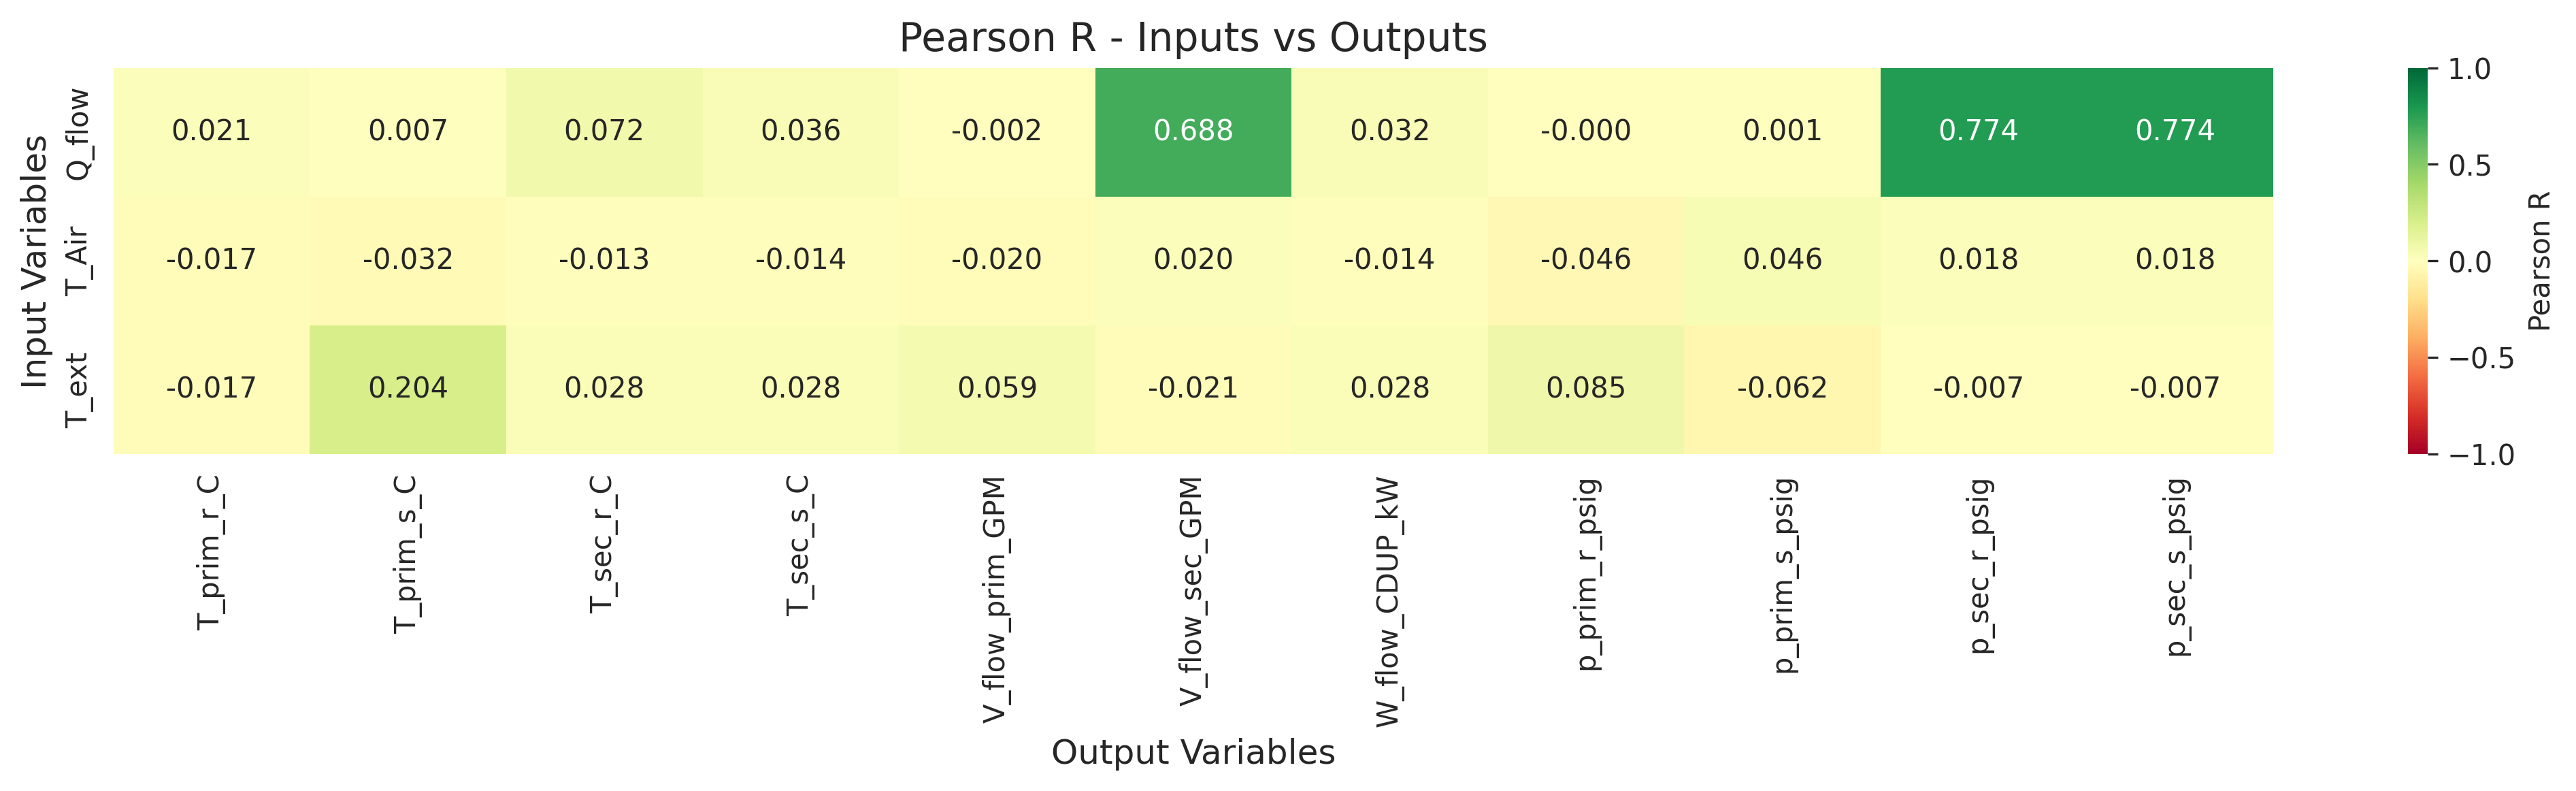

In [15]:
# Correlation Heatmaps
create_correlation_heatmap(metrics_df, OUTPUT_DIR, n_workers=N_WORKERS)
print(f"Heatmaps saved to {OUTPUT_DIR}")

# Display one heatmap inline
from IPython.display import Image
Image(filename=os.path.join(OUTPUT_DIR, 'heatmap_pearson_r.png'))


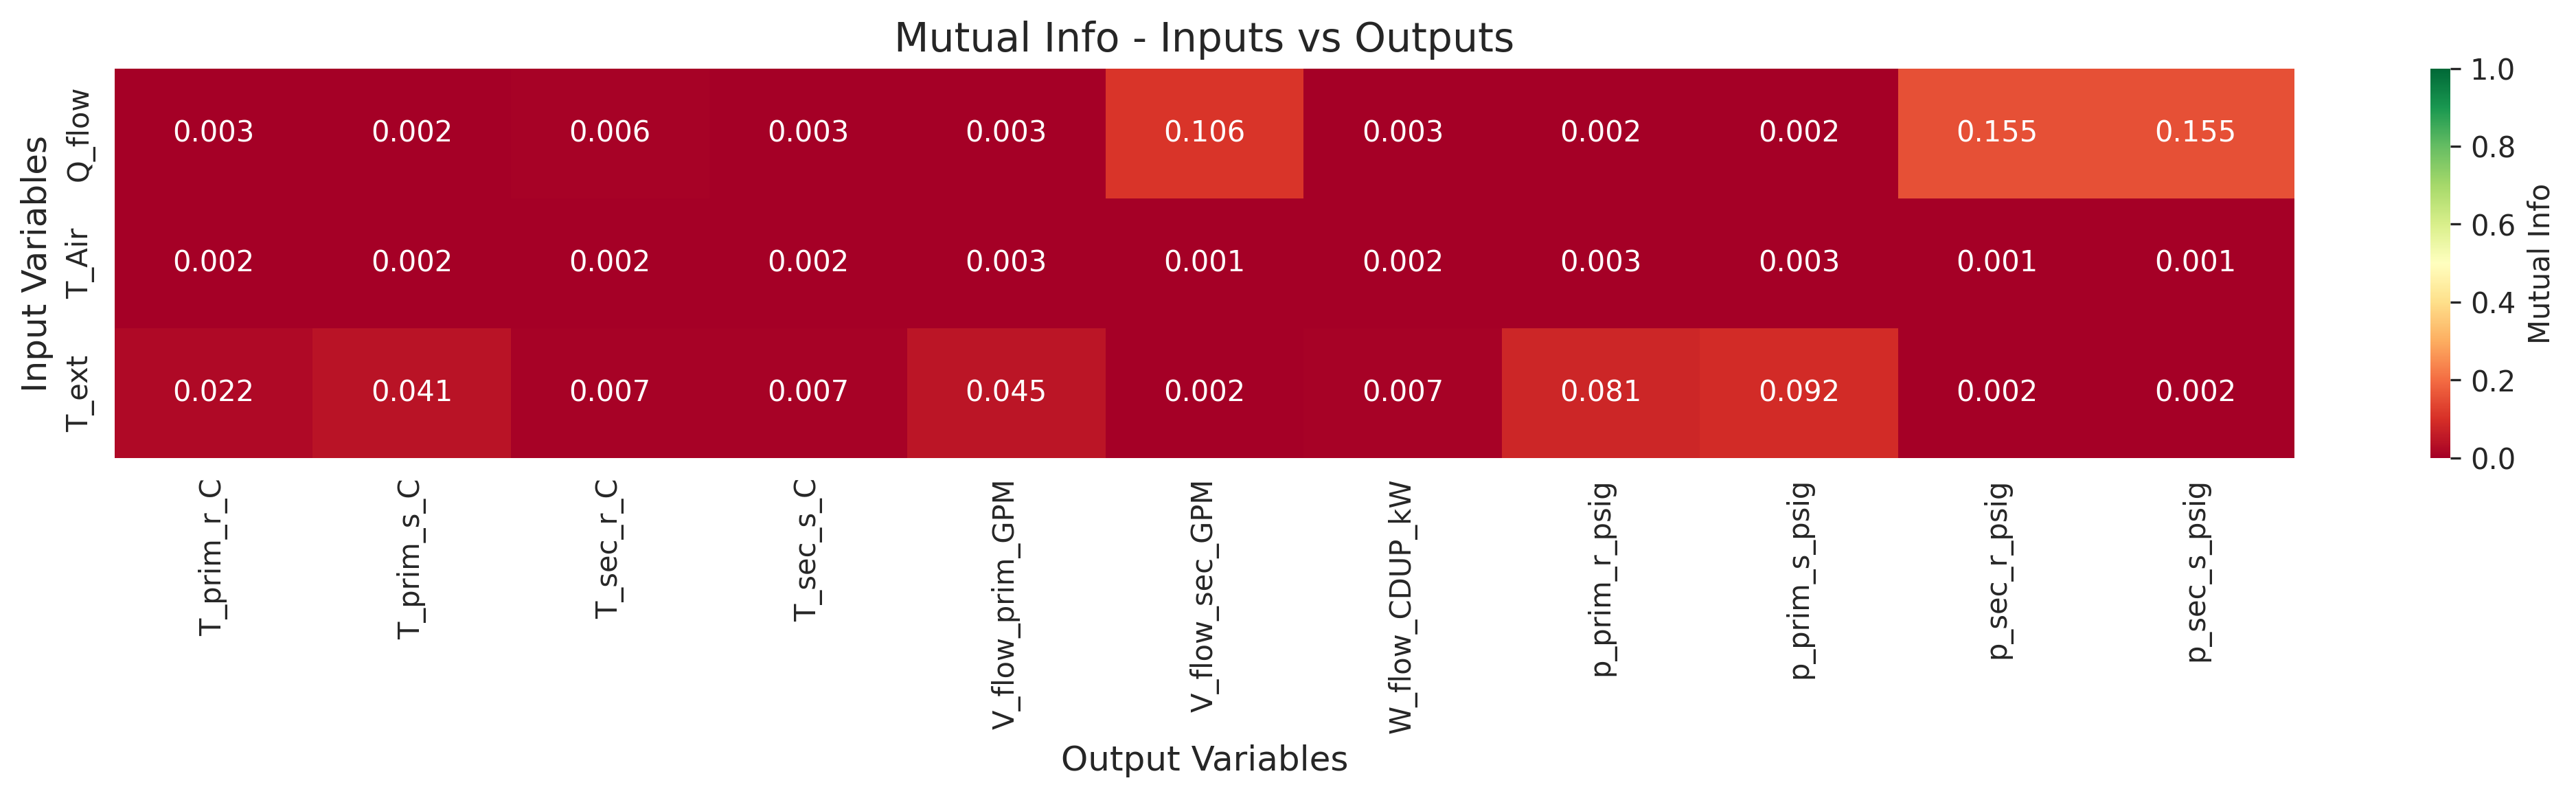

In [16]:
Image(filename=os.path.join(OUTPUT_DIR, 'heatmap_mutual_info.png'))
# heatmap_mutual_info.png   heatmap_r2_score.png     
# heatmap_pearson_r.png     heatmap_spearman_r.png   

## Isolated Effects Analysis

In [17]:
# After running analyze_isolated_effects
isolated_df = analyzer.analyze_isolated_effects(prepared_data, tolerance=0.1)


2026-02-03 19:21:18 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Analyzing isolated input effects (others held at mean)...
2026-02-03 19:21:18 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO -   Q_flow: 1145 samples with others at mean
2026-02-03 19:21:18 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO -   T_Air: 1321 samples with others at mean
2026-02-03 19:21:18 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO -   T_ext: 1384 samples with others at mean


In [18]:

# Create visualizations
create_isolated_effect_heatmap(isolated_df, output_dir=OUTPUT_DIR)
create_isolated_effect_comparison(metrics_df, isolated_df, output_dir=OUTPUT_DIR)
create_isolated_effect_summary(isolated_df, output_dir=OUTPUT_DIR)

2026-02-03 19:21:18 - fmu2ml.analysis.input_output_relations.visualizers.isolated_effect_visualizer - INFO - Creating isolated effect heatmaps...
2026-02-03 19:21:20 - fmu2ml.analysis.input_output_relations.visualizers.isolated_effect_visualizer - INFO - Created isolated effect heatmaps for 3 metrics
2026-02-03 19:21:20 - fmu2ml.analysis.input_output_relations.visualizers.isolated_effect_visualizer - INFO - Creating isolated vs full effect comparison plots...
2026-02-03 19:21:26 - fmu2ml.analysis.input_output_relations.visualizers.isolated_effect_visualizer - INFO - Created comparison plots for 3 inputs
2026-02-03 19:21:26 - fmu2ml.analysis.input_output_relations.visualizers.isolated_effect_visualizer - INFO - Creating isolated effect summary plots...
2026-02-03 19:21:28 - fmu2ml.analysis.input_output_relations.visualizers.isolated_effect_visualizer - INFO - Created isolated effect summary plot


2026-02-03 19:21:28 - fmu2ml.analysis.input_output_relations.visualizers.scatter_visualizer - INFO - Creating scatter plots in parallel...
2026-02-03 19:21:33 - fmu2ml.analysis.input_output_relations.visualizers.scatter_visualizer - INFO - Created scatter plots for 3 inputs


Scatter plots saved to ../results/lassen/data_analysis/direct_effect_analysis


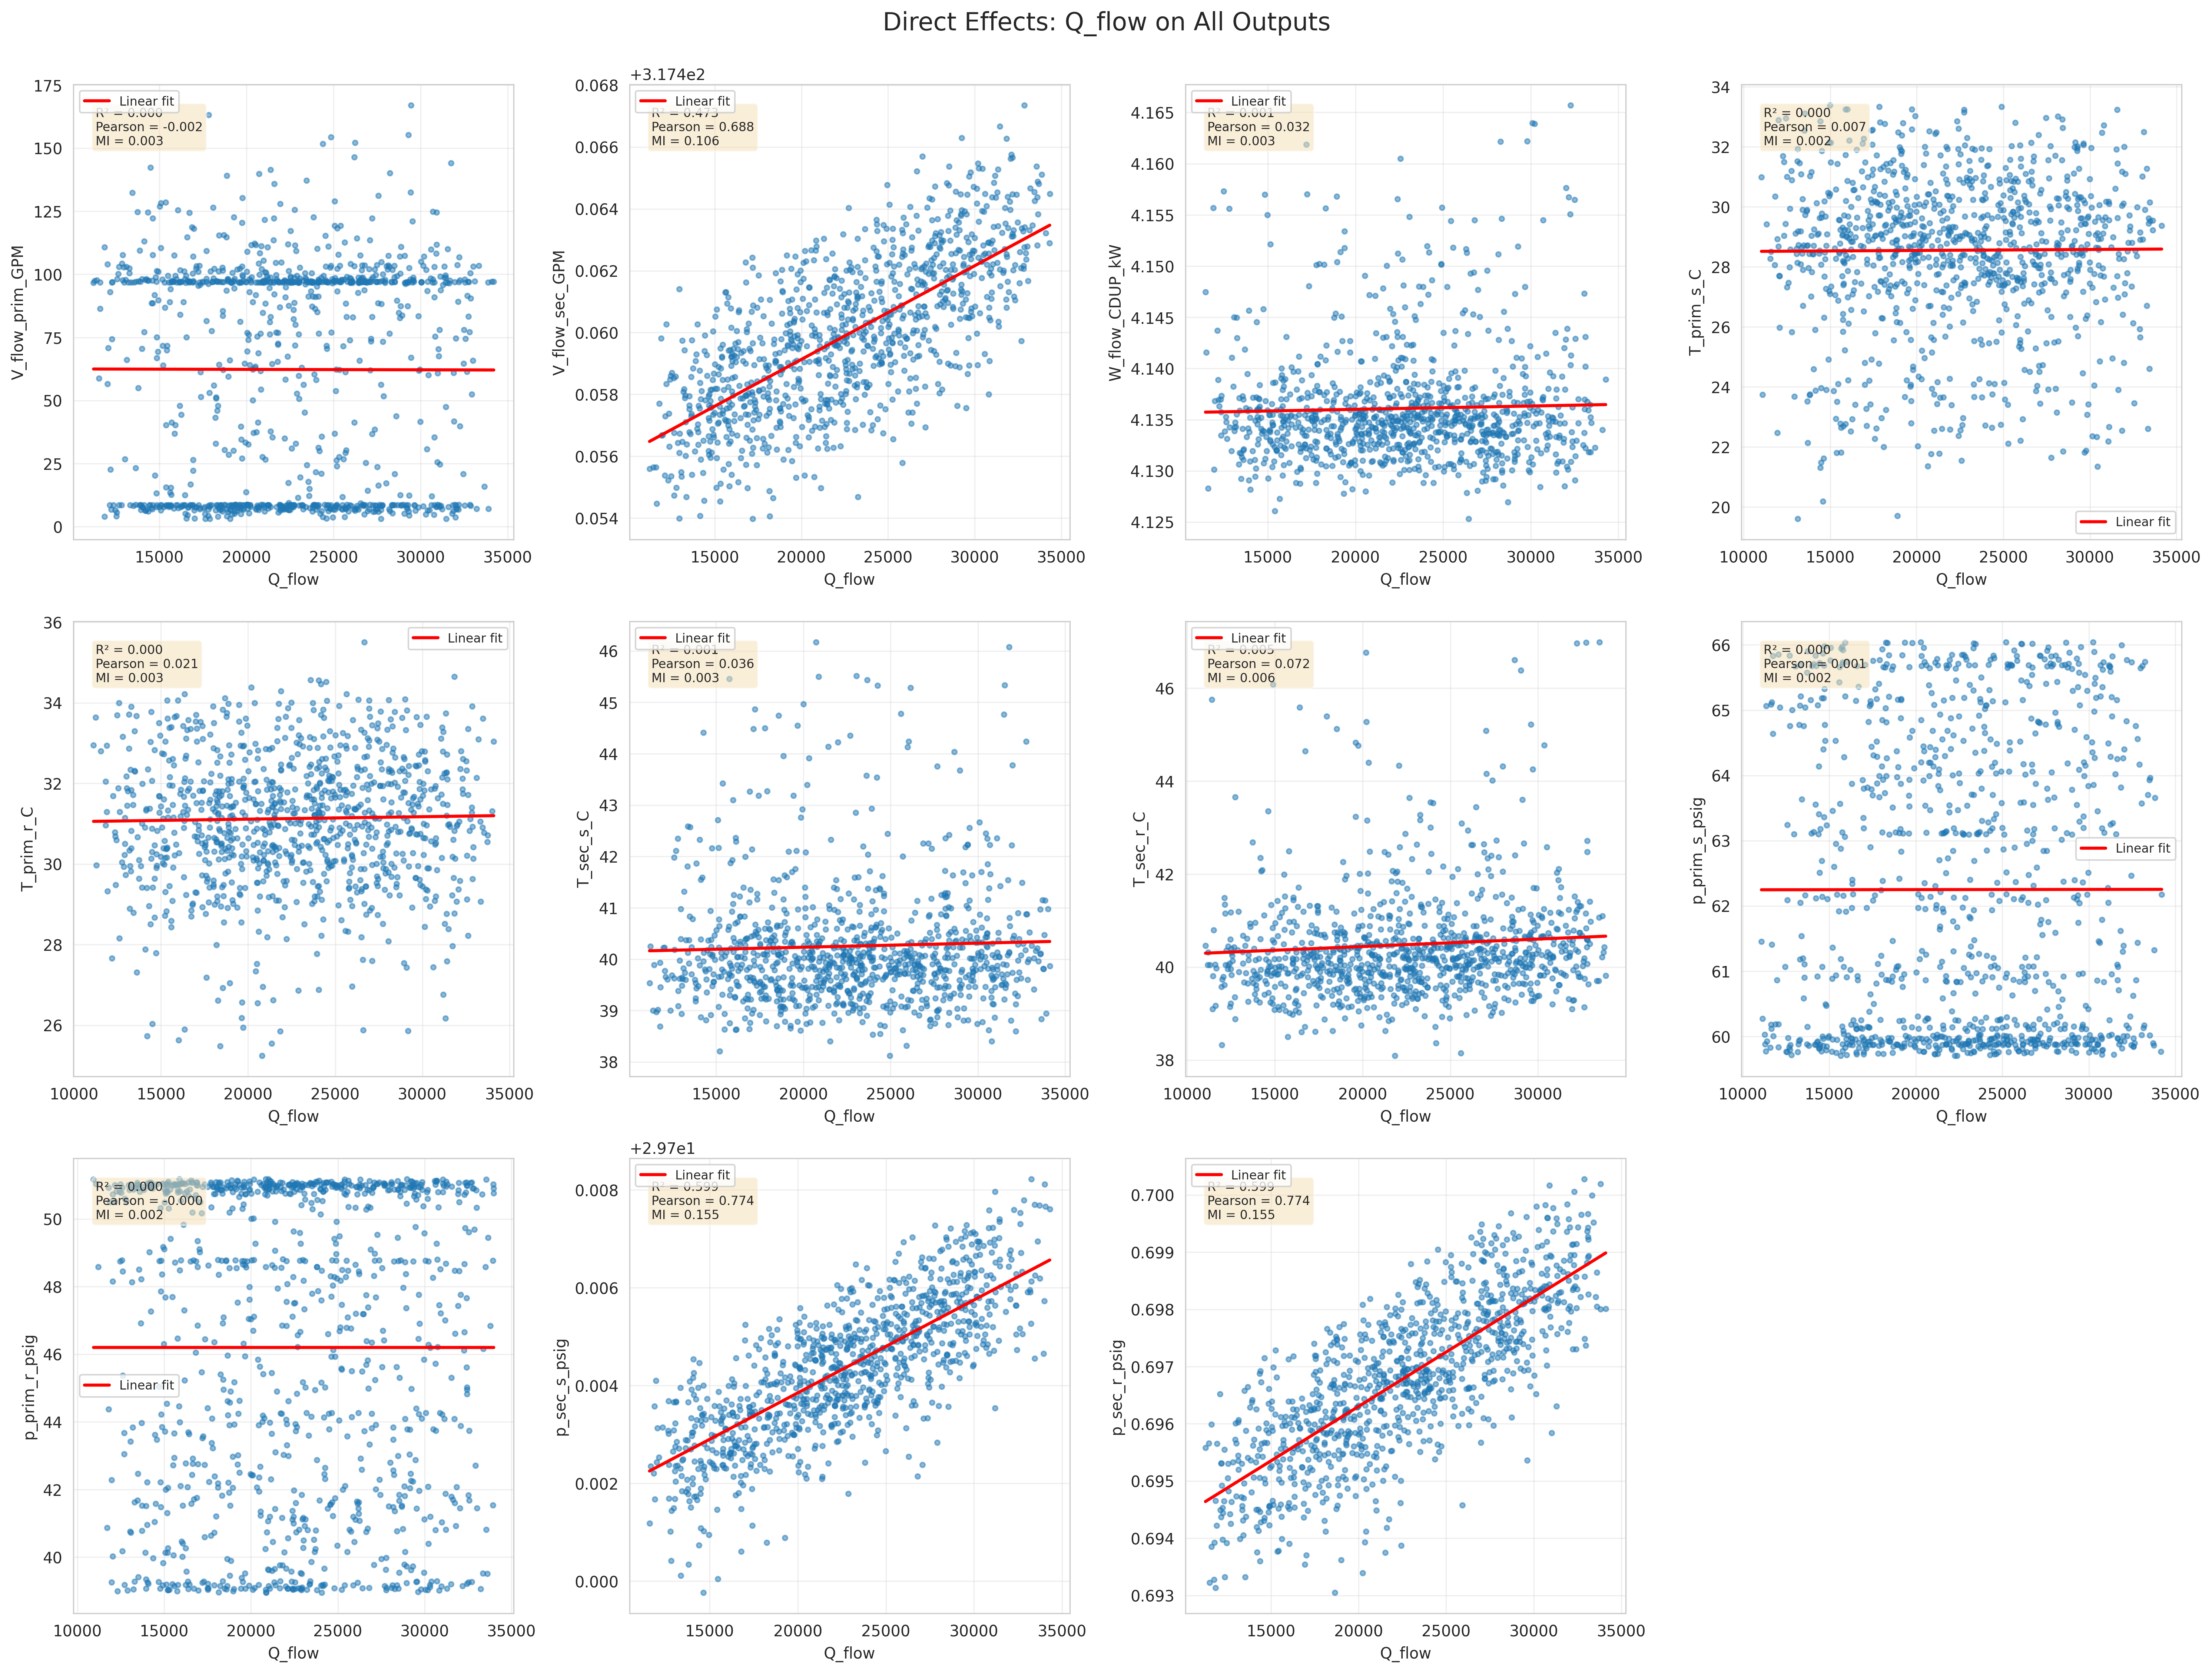

In [19]:
# Scatter Plots for Key Relationships
create_scatter_plots(prepared_data, metrics_df, OUTPUT_DIR, n_workers=N_WORKERS)
print(f"Scatter plots saved to {OUTPUT_DIR}")

# Display example scatter plot
Image(filename=os.path.join(OUTPUT_DIR, 'scatter_plots_Q_flow.png'))
# scatter_plots_T_ext.png   scatter_plots_T_Air.png

In [21]:
# Image(filename=os.path.join(OUTPUT_DIR, 'scatter_plots_T_air.png'))


2026-02-03 19:21:50 - fmu2ml.analysis.input_output_relations.visualizers.ranking_visualizer - INFO - Creating importance ranking plots...
2026-02-03 19:21:52 - fmu2ml.analysis.input_output_relations.visualizers.ranking_visualizer - INFO - Saved importance ranking plots to ../results/lassen/data_analysis/direct_effect_analysis


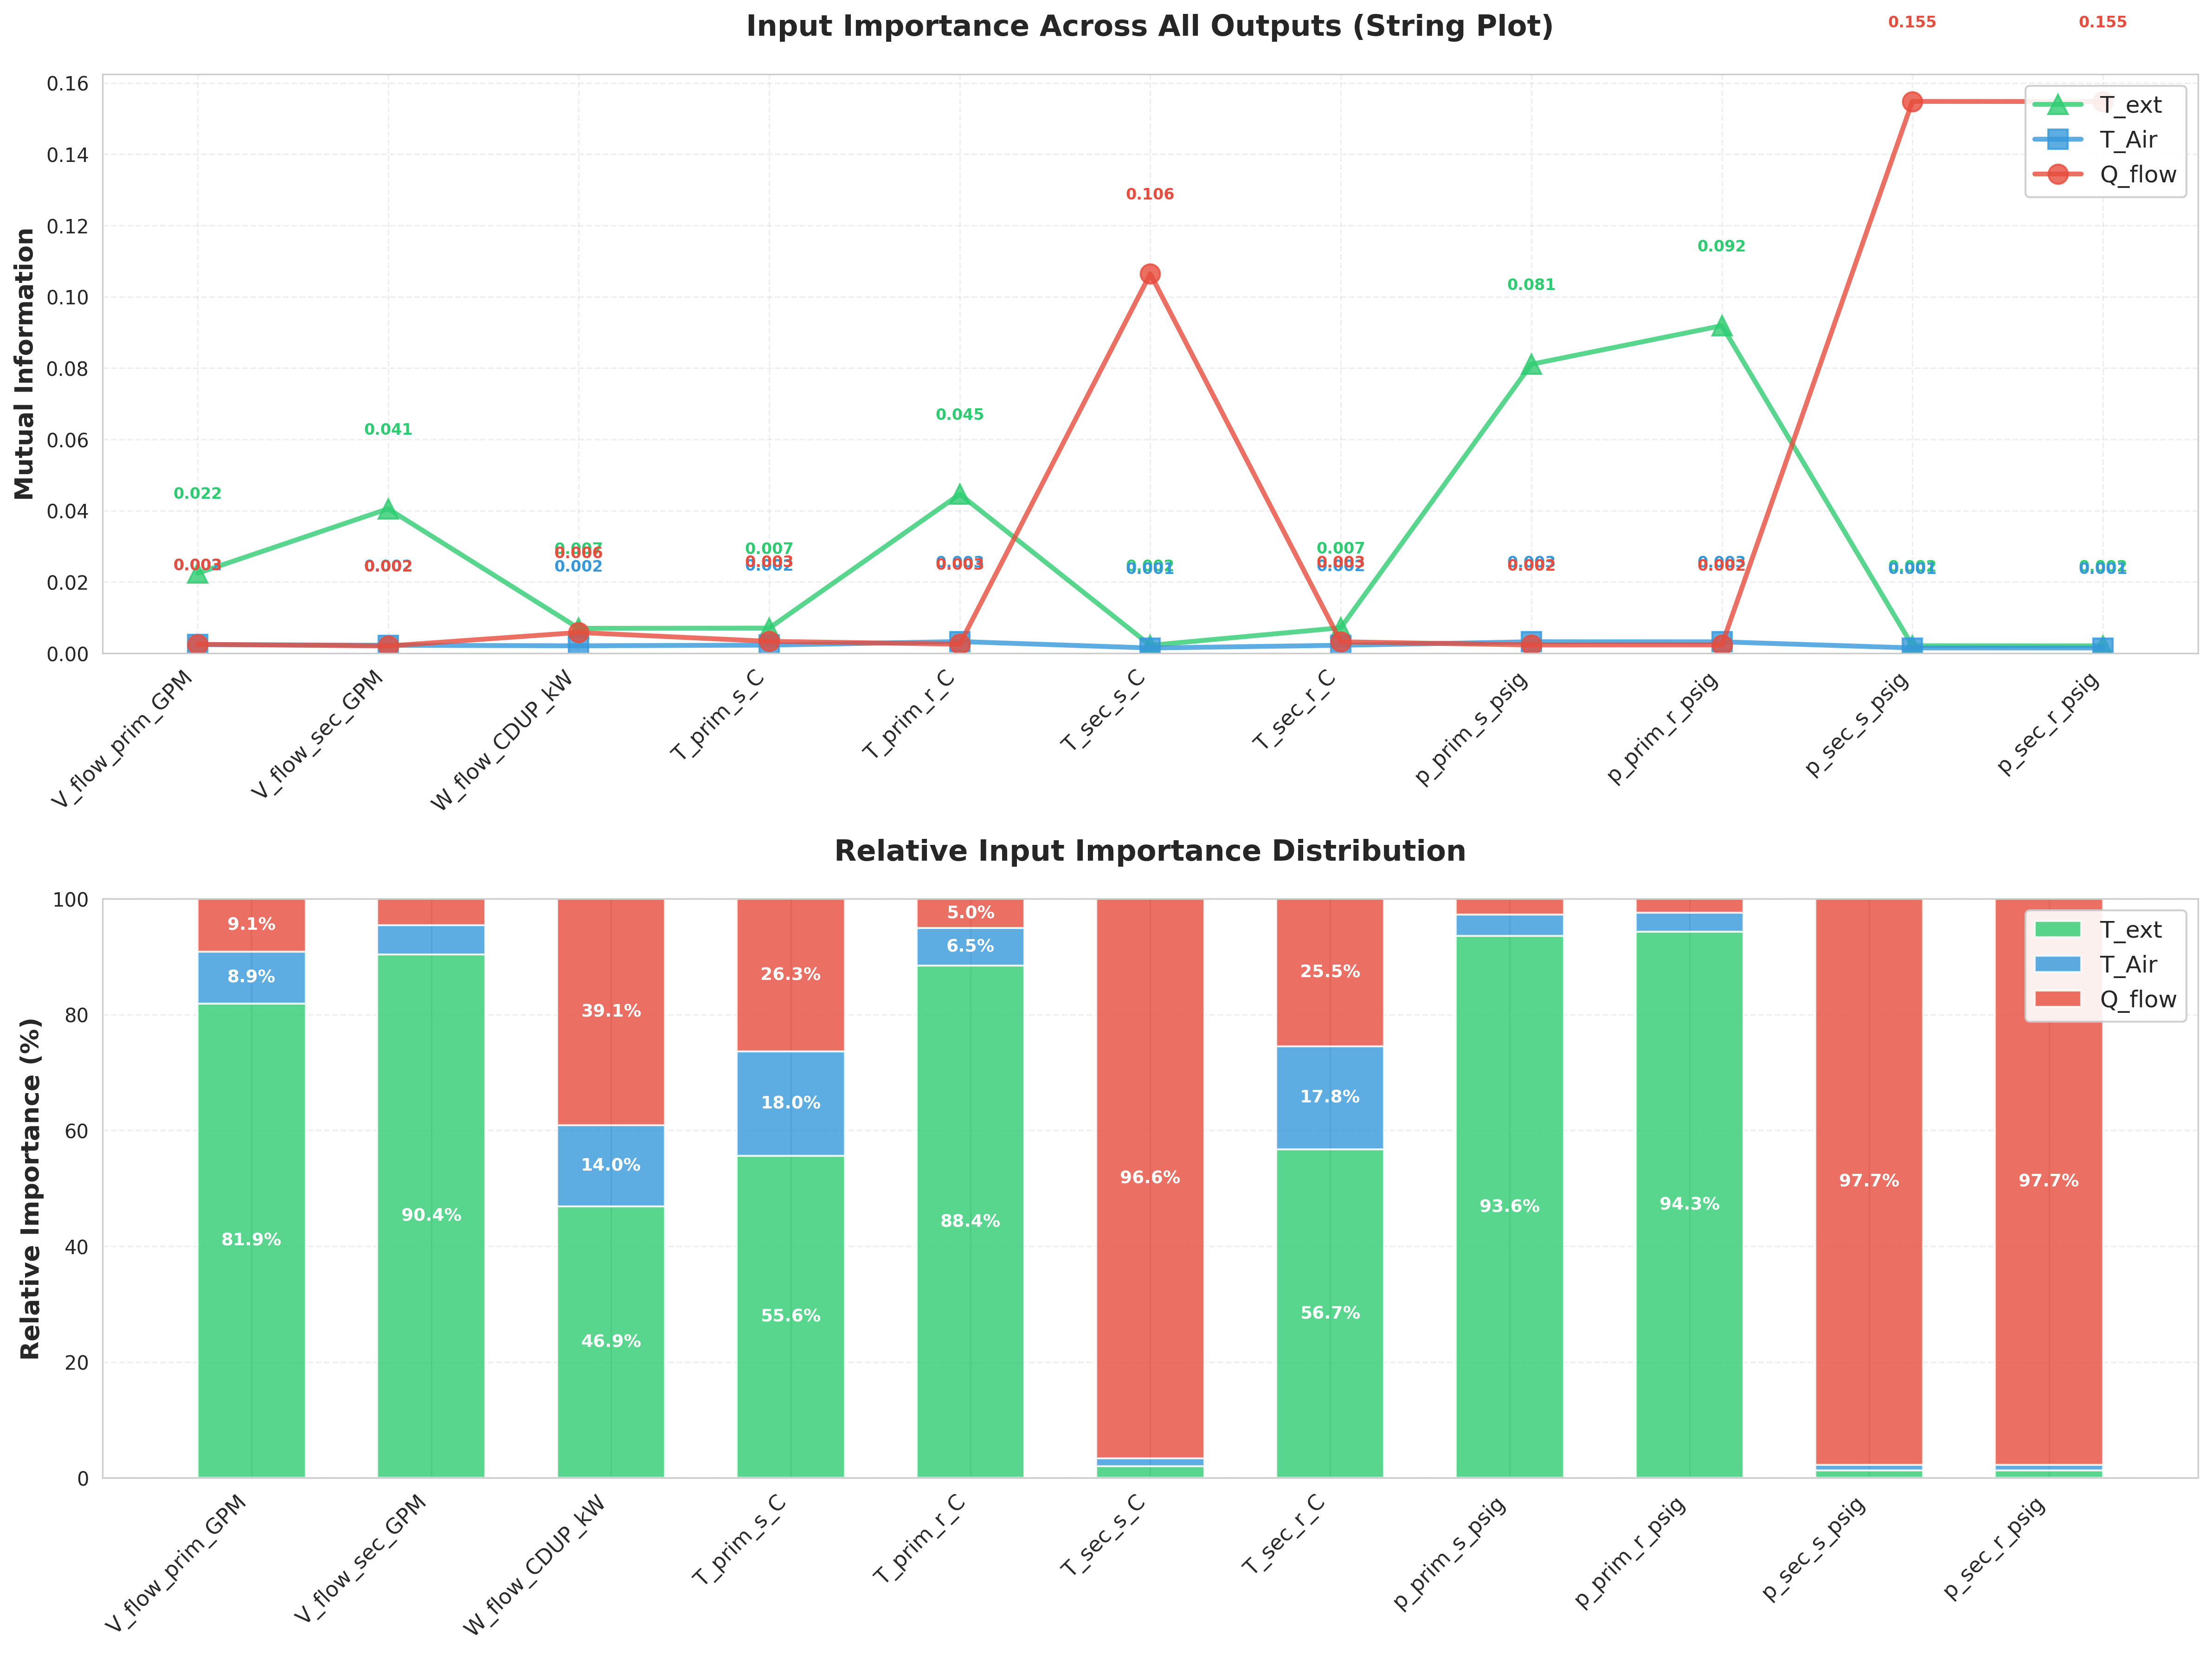

In [22]:
# Importance Ranking Plots
create_importance_ranking_plots(rankings_df, OUTPUT_DIR)
Image(filename=os.path.join(OUTPUT_DIR, 'importance_rankings.png'))


## Interaction Effects Analysis


In [23]:
print("Analyzing interaction effects...")
interaction_df = analyzer.analyze_all_interaction_effects(prepared_data)


2026-02-03 19:22:08 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Analyzing interaction effects for all outputs in parallel...
2026-02-03 19:22:08 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Executing 11 interaction analysis tasks...


Analyzing interaction effects...


In [24]:
interaction_df

,output,r2_linear,r2_polynomial,interaction_effect
0,V_flow_prim_GPM,0.003900,0.004730,0.000830
1,V_flow_sec_GPM,0.474281,0.474811,0.000530
2,W_flow_CDUP_kW,0.001945,0.002963,0.001017
3,T_prim_s_C,0.042741,0.043058,0.000317
4,T_prim_r_C,0.001053,0.002643,0.001590
5,T_sec_s_C,0.002201,0.003226,0.001024
6,T_sec_r_C,0.006091,0.007107,0.001015
7,p_prim_s_psig,0.005905,0.007098,0.001193
8,p_prim_r_psig,0.009388,0.010509,0.001121
9,p_sec_s_psig,0.599429,0.599964,0.000535


## Response Surfaces Analysis

In [ ]:
key_outputs = ['T_prim_r_C', 'W_flow_CDUP_kW', 'V_flow_prim_GPM']
# key_outputs = ['T_sec_s_C','p_sec_s_psig','p_prim_r_psig']
input_pairs = [('Q_flow', 'T_Air'), ('Q_flow', 'T_ext'), ('T_Air', 'T_ext')]

# Fixed inputs (middle of ranges)
fixed_inputs = {
    'Q_flow': (INPUT_RANGES['Q_flow'][0] + INPUT_RANGES['Q_flow'][1]) / 2 * 1000,
    'T_Air': (INPUT_RANGES['T_Air'][0] + INPUT_RANGES['T_Air'][1]) / 2,
    'T_ext': (INPUT_RANGES['T_ext'][0] + INPUT_RANGES['T_ext'][1]) / 2
}

# Generate all response surface data
all_surface_data = {}
for input1, input2 in input_pairs:
    print(f"Generating surface data: {input1} x {input2}")
    
    # Remove varying inputs from fixed_inputs
    current_fixed = {k: v for k, v in fixed_inputs.items() 
                    if k not in (input1, input2)}
    
    # Set ranges with unit conversion for Q_flow
    input1_range = (INPUT_RANGES[input1][0]*1000, INPUT_RANGES[input1][1]*1000) if input1 == 'Q_flow' else INPUT_RANGES[input1]
    input2_range = (INPUT_RANGES[input2][0]*1000, INPUT_RANGES[input2][1]*1000) if input2 == 'Q_flow' else INPUT_RANGES[input2]
    
    surface_data = data_generator.generate_response_surface_data(
        input1=input1, 
        input2=input2,
        input1_range=input1_range,
        input2_range=input2_range,
        n_points_per_dim=20,
        fixed_inputs=current_fixed,
        n_workers=N_WORKERS,
        use_parallel=True
    )
    
    all_surface_data[(input1, input2)] = surface_data

# Compute response surfaces using DirectEffectAnalyzer
surfaces = {}
for output in key_outputs:
    for input1, input2 in input_pairs:
        print(f"Computing surface: {output} vs {input1} x {input2}")
        
        surface_data = all_surface_data[(input1, input2)]
        surface_prepared = analyzer.prepare_data(surface_data)
        
        # Use the static method directly
        input1_data = surface_prepared['inputs'][input1]
        input2_data = surface_prepared['inputs'][input2]
        output_data = surface_prepared['outputs'][output]
        
        X, Y, Z = analyzer._compute_response_surface_static(
            input1_data, input2_data, output_data, n_points=20
        )
        
        surfaces[(output, input1, input2)] = (X, Y, Z)

# Create plots
create_response_surface_plots(surfaces, OUTPUT_DIR, n_workers=N_WORKERS)

# Display first plot
Image(filename=os.path.join(OUTPUT_DIR, f'response_surface_{key_outputs[0]}_Q_flow_T_Air.png'))

In [21]:
Image(filename=os.path.join(OUTPUT_DIR,'response_surface_W_flow_CDUP_kW_Q_flow_T_ext.png'))


In [22]:
Image(filename=os.path.join(OUTPUT_DIR,'response_surface_V_flow_prim_GPM_Q_flow_T_ext.png'))


2026-02-03 19:22:28 - fmu2ml.analysis.input_output_relations.visualizers.slice_visualizer - INFO - Creating slice plots: T_prim_r_C vs Q_flow at different T_ext levels...
2026-02-03 19:22:29 - fmu2ml.analysis.input_output_relations.visualizers.slice_visualizer - INFO - Created slice plots for 1 outputs


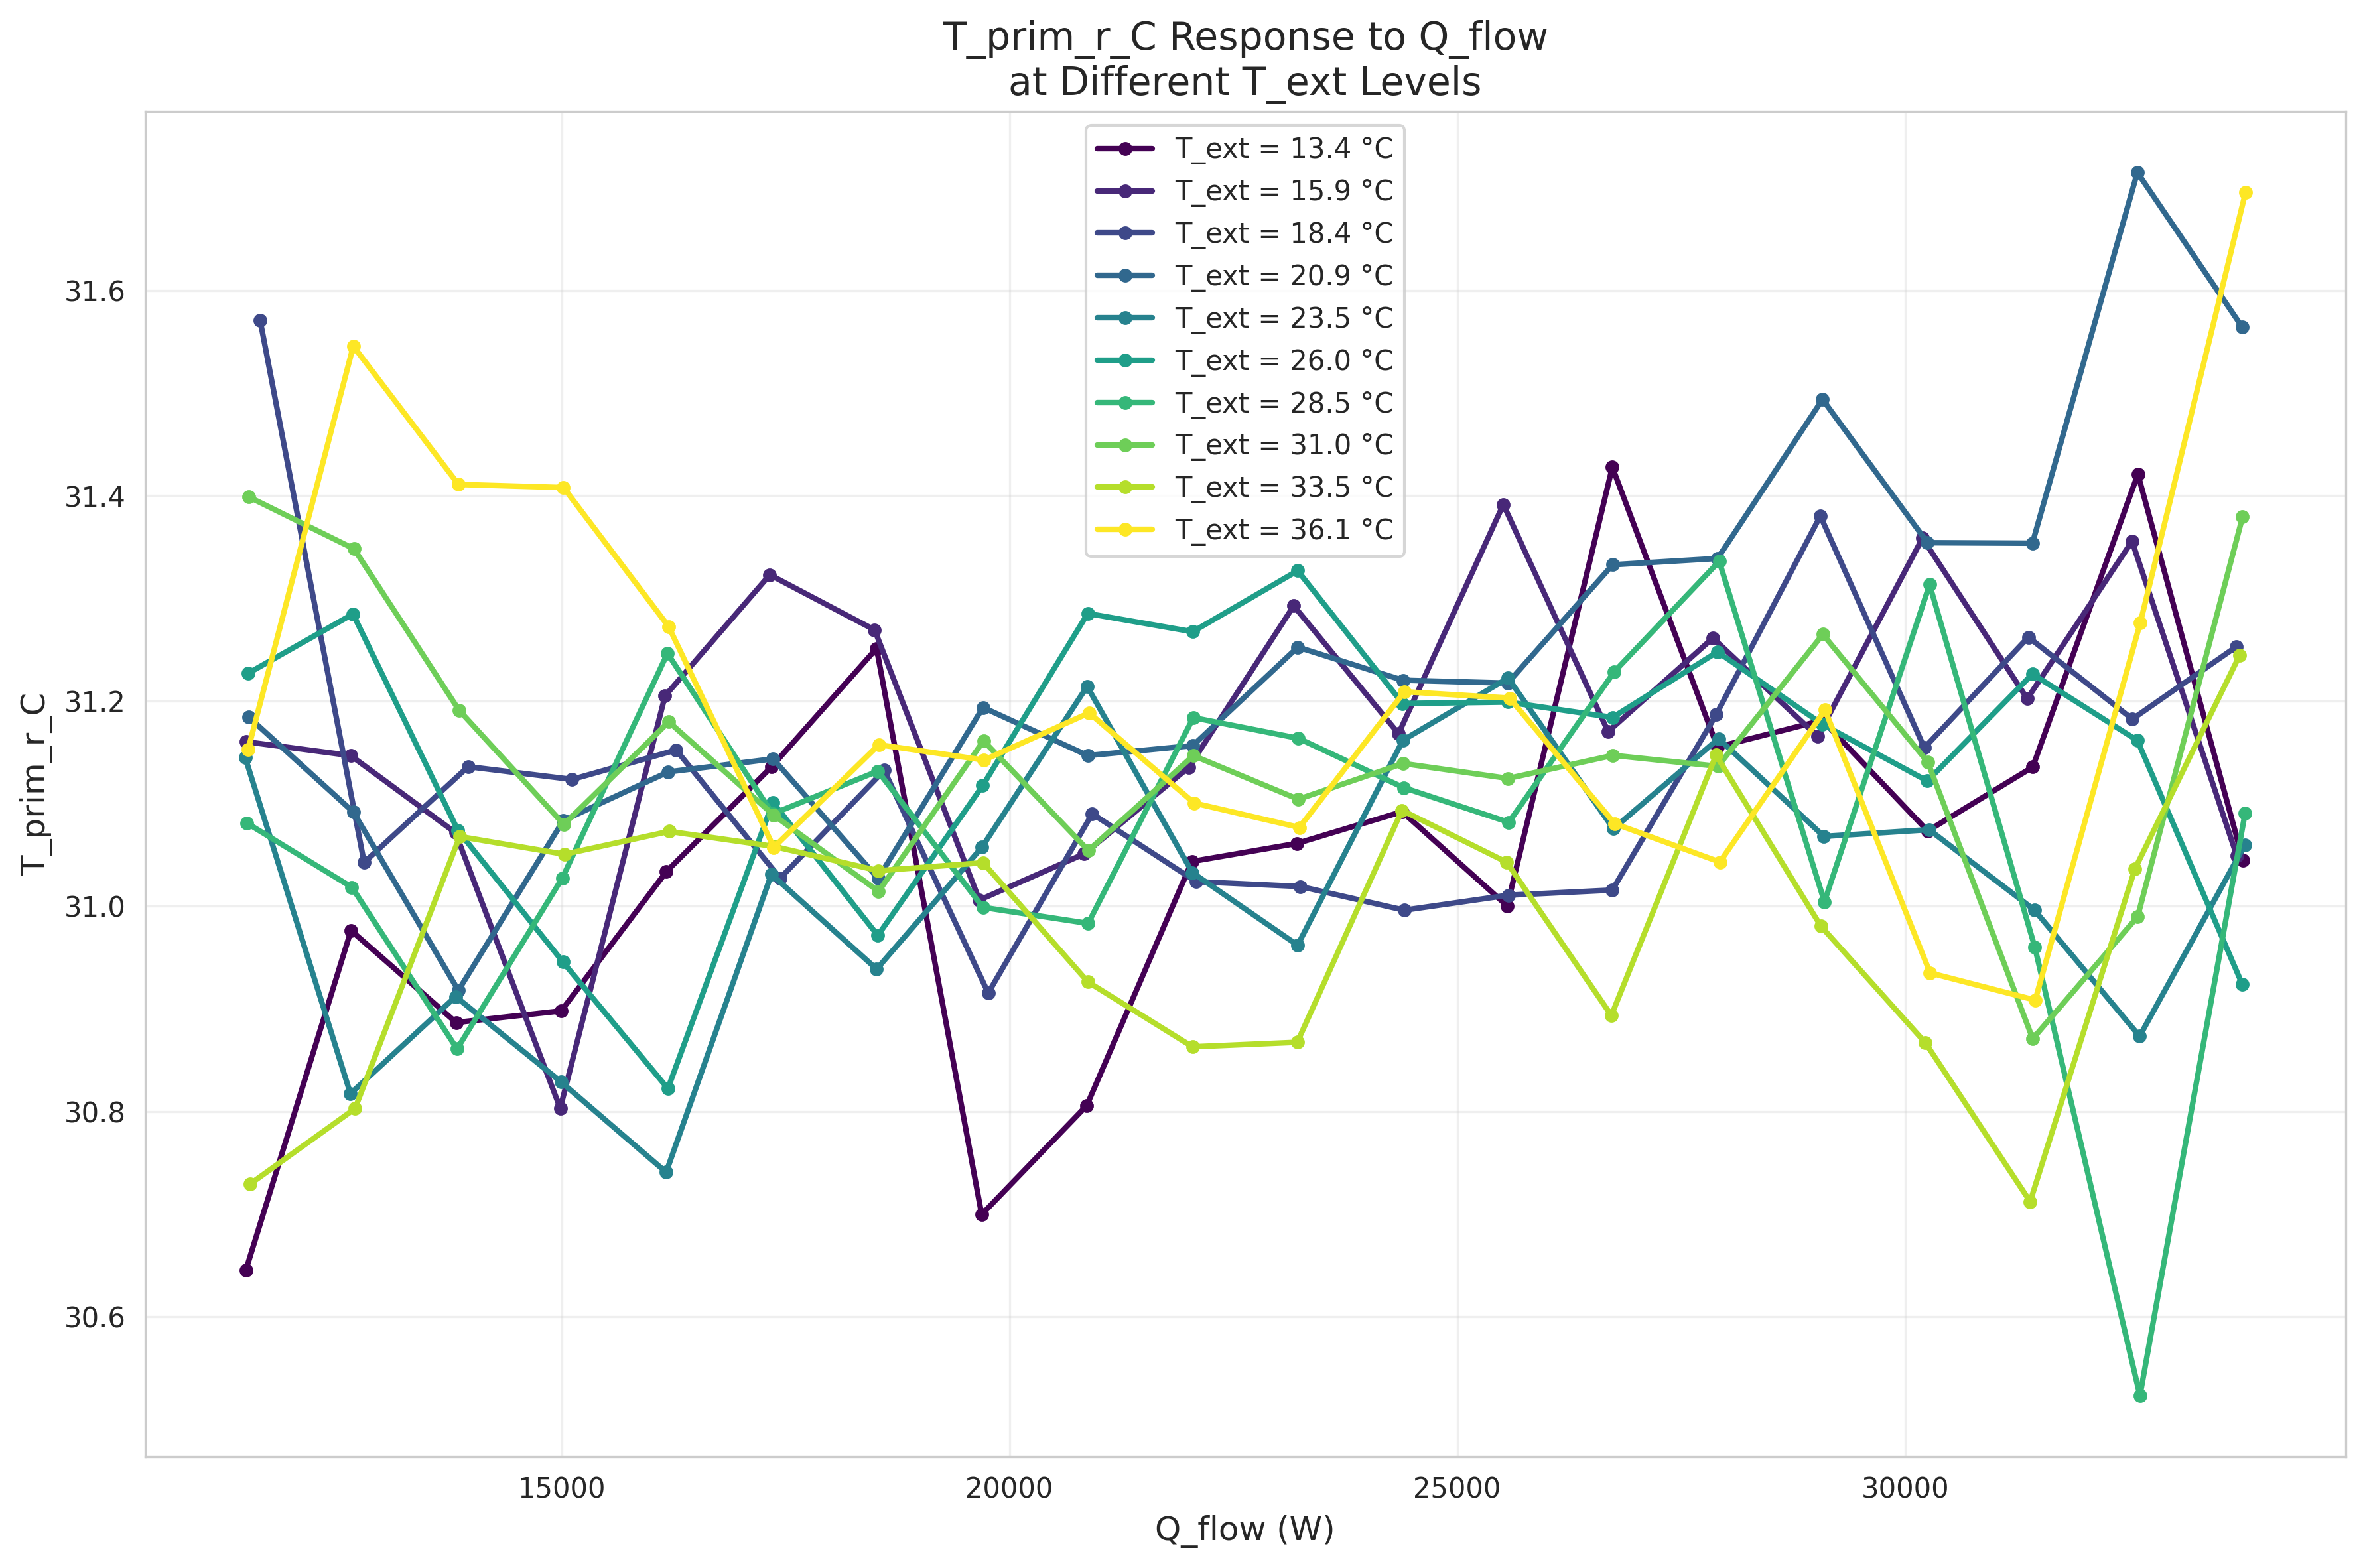

In [25]:

# Slice Plots
create_slice_plots(
    prepared_data,
    output_vars=['T_prim_r_C'],
    input1='Q_flow',
    input2='T_ext',
    n_slices=10,
    output_dir=OUTPUT_DIR
)
Image(filename=os.path.join(OUTPUT_DIR, 'slice_plot_T_prim_r_C_Q_flow_vs_T_ext.png'))


## Summary Statistics


In [26]:
print("="*60)
print("ANALYSIS SUMMARY")
print("="*60)

print(f"\nTotal input-output pairs analyzed: {len(metrics_df)}")
print(f"Strong correlations (|r| > 0.7): {len(metrics_df[abs(metrics_df['pearson_r']) > 0.7])}")
print(f"High mutual information (> 0.5): {len(metrics_df[metrics_df['mutual_info'] > 0.5])}")
print(f"Good fits (R² > 0.8): {len(metrics_df[metrics_df['r2_score'] > 0.8])}")

print("\nTop 3 most important inputs overall:")
overall_importance = metrics_df.groupby('input')['mutual_info'].mean().sort_values(ascending=False)
print(overall_importance.head(3))


ANALYSIS SUMMARY

Total input-output pairs analyzed: 33
Strong correlations (|r| > 0.7): 2
High mutual information (> 0.5): 0
Good fits (R² > 0.8): 0

Top 3 most important inputs overall:
input
Q_flow    0.040020
T_ext     0.028023
T_Air     0.002317
Name: mutual_info, dtype: float64


In [27]:

# Save Results
metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'sensitivity_metrics.csv'), index=False)
rankings_df.to_csv(os.path.join(OUTPUT_DIR, 'input_rankings.csv'), index=False)
interaction_df.to_csv(os.path.join(OUTPUT_DIR, 'interaction_effects.csv'), index=False)

print(f"\nResults saved to: {OUTPUT_DIR}")



Results saved to: ../results/lassen/data_analysis/direct_effect_analysis


In [28]:

# Cleanup
analyzer._close_dask_client()
print("Analysis complete!")

2026-02-03 19:22:30 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Closing Dask cluster...
2026-02-03 19:22:30 - fmu2ml.analysis.input_output_relations.analyzers.direct_effect_analyzer - INFO - Dask client closed


Analysis complete!
